# Part A — Profiling, cleaning, and the data story

In [48]:
#Task 1 — Load, profile, and save raw fallback
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [50]:
df = sns.load_dataset("titanic")
missing_pct = df.isnull().mean() * 100
missing_summary = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": missing_pct
})
missing_summary = missing_summary[
    missing_summary["Missing Count"] > 0
]
missing_summary.round(2)

,Missing Count,Missing Percentage
age,177,19.87
embarked,2,0.22
deck,688,77.22
embark_town,2,0.22


In [4]:
#Load raw dataset once
df = sns.load_dataset("titanic")

print("Dataset information:")
df.info()

print("\nDescriptive statistics:")
print(df.describe())

print("\nDataset shape:")
print(df.shape)

print("\nMissing values (%):")
missing_pct = df.isnull().mean() * 100
print(missing_pct[missing_pct > 0].round(2))

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB

Descriptive statistics:
         survived      pclass         age       

In [10]:
df.to_csv("titanic.csv", index=False)

print("Raw dataset saved to titanic.csv")

Raw dataset saved to titanic.csv


In [11]:
#Task 2 — Missing-value handling
missing_pct = df.isnull().mean() * 100
affected_columns = missing_pct[missing_pct > 0]

print("Missing-value percentages:")
print(affected_columns.round(2))

Missing-value percentages:
Series([], dtype: float64)


In [13]:
df["age"] = df["age"].fillna(df["age"].median())

df = df.dropna(subset=["embarked", "embark_town"]).copy()

# >30% missing -> retain missingness as its own category
df["deck"] = df["deck"].astype(object).fillna("Unknown").astype("category")

In [14]:
print("\nMissing values after cleaning:")
print(df.isnull().sum())

print("\nCleaned dataset shape:")
print(df.shape)


Missing values after cleaning:
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
deck           0
embark_town    0
alive          0
alone          0
dtype: int64

Cleaned dataset shape:
(889, 15)


## Missing-Value Handling

The missing-value percentage was measured before any cleaning.

- `age`: 19.87% missing. This is between 5% and 30%, so the missing values
  were imputed using the median. Median imputation is appropriate for this
  numeric variable because it is less affected by extreme values than the mean.
- `embarked`: 0.22% missing. Because this is below 5%, the affected rows were
  dropped.
- `embark_town`: 0.22% missing. Because this is below 5%, the affected rows
  were dropped.
- `who`: 0.11% missing. Because this is below 5%, the affected rows were
  dropped.
- `deck`: 77.22% missing. This is substantially above the 30% threshold, so
  imputing a particular deck would be unreliable. Instead, missing values were
  retained as an explicit `Unknown` category.

This approach preserves useful information about missingness while following
the specified threshold rule.

In [15]:
df.to_csv("cleaned_titanic.csv", index=False) #Save cleaned data

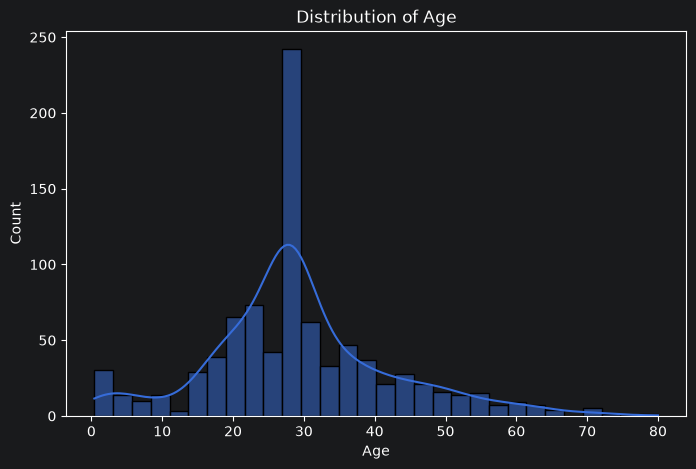

In [22]:
#Task 3 — Univariate analysis
#Age histogram and box plot
plt.figure(figsize=(8, 5))
sns.histplot(df["age"], bins=30, kde=True)
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

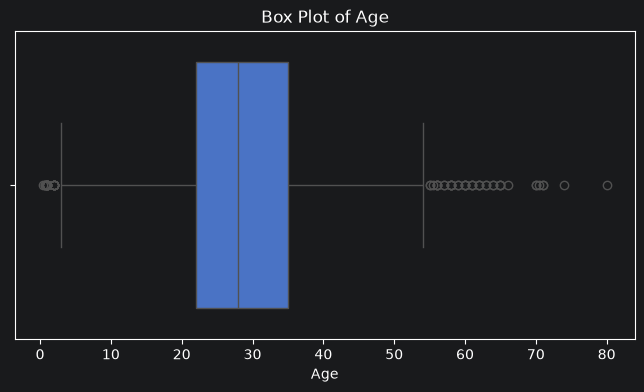

In [19]:
#Box plot
plt.figure(figsize=(8, 4))
sns.boxplot(x=df["age"])
plt.title("Box Plot of Age")
plt.xlabel("Age")
plt.show()

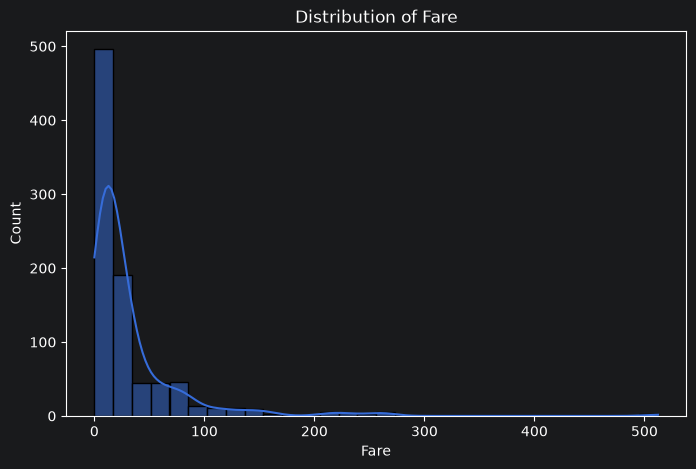

In [23]:
#Fare histogram and box plot
plt.figure(figsize=(8, 5))
sns.histplot(df["fare"], bins=30, kde=True)
plt.title("Distribution of Fare")
plt.xlabel("Fare")
plt.ylabel("Count")
plt.show()

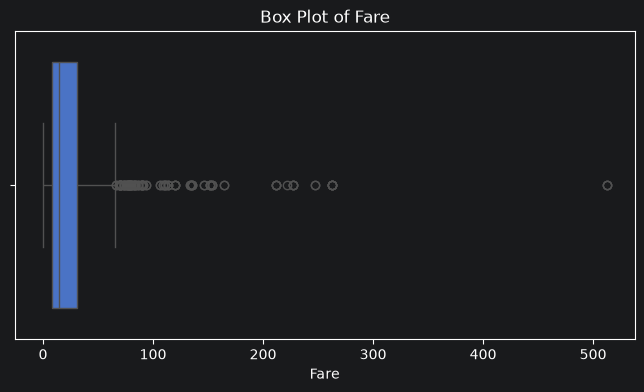

In [24]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df["fare"])
plt.title("Box Plot of Fare")
plt.xlabel("Fare")
plt.show()

In [25]:
#IQR outlier calculation
def count_iqr_outliers(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers = series[(series < lower_bound) | (series > upper_bound)]

    return {
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "outlier_count": len(outliers)
    }


age_outliers = count_iqr_outliers(df["age"])
fare_outliers = count_iqr_outliers(df["fare"])

print("Age IQR analysis:")
print(age_outliers)

print("\nFare IQR analysis:")
print(fare_outliers)

Age IQR analysis:
{'Q1': np.float64(22.0), 'Q3': np.float64(35.0), 'IQR': np.float64(13.0), 'lower_bound': np.float64(2.5), 'upper_bound': np.float64(54.5), 'outlier_count': 65}

Fare IQR analysis:
{'Q1': np.float64(7.8958), 'Q3': np.float64(31.0), 'IQR': np.float64(23.1042), 'lower_bound': np.float64(-26.7605), 'upper_bound': np.float64(65.6563), 'outlier_count': 114}


In [26]:
fare_mean = df["fare"].mean()
fare_median = df["fare"].median()
fare_mode = df["fare"].mode().iloc[0]

print(f"Fare mean: {fare_mean:.2f}")
print(f"Fare median: {fare_median:.2f}")
print(f"Fare mode: {fare_mode:.2f}")

Fare mean: 32.10
Fare median: 14.45
Fare mode: 8.05


In [27]:
if fare_mean > fare_median > fare_mode:
    print("Fare is right-skewed.")
elif fare_mean < fare_median < fare_mode:
    print("Fare is left-skewed.")
else:
    print("Fare does not follow a simple mean > median > mode or mean < median < mode ordering.")

Fare is right-skewed.


In [30]:
#Task 4 — Bivariate analysis
#Survival by sex
male_survival = df.loc[df["sex"] == "male", "survived"].mean()
female_survival = df.loc[df["sex"] == "female", "survived"].mean()

print(f"Male survival rate: {male_survival:.2%}")
print(f"Female survival rate: {female_survival:.2%}")

Male survival rate: 18.89%
Female survival rate: 74.04%


In [31]:
#Survival by passenger class
first_class_survival = df.loc[df["pclass"] == 1, "survived"].mean()
second_class_survival = df.loc[df["pclass"] == 2, "survived"].mean()
third_class_survival = df.loc[df["pclass"] == 3, "survived"].mean()

print(f"1st class survival rate: {first_class_survival:.2%}")
print(f"2nd class survival rate: {second_class_survival:.2%}")
print(f"3rd class survival rate: {third_class_survival:.2%}")

1st class survival rate: 62.62%
2nd class survival rate: 47.28%
3rd class survival rate: 24.24%


In [32]:
#Survival by sex AND class
female_first = df.loc[
    (df["sex"] == "female") & (df["pclass"] == 1),
    "survived"
].mean()

female_second = df.loc[
    (df["sex"] == "female") & (df["pclass"] == 2),
    "survived"
].mean()

female_third = df.loc[
    (df["sex"] == "female") & (df["pclass"] == 3),
    "survived"
].mean()

male_first = df.loc[
    (df["sex"] == "male") & (df["pclass"] == 1),
    "survived"
].mean()

male_second = df.loc[
    (df["sex"] == "male") & (df["pclass"] == 2),
    "survived"
].mean()

male_third = df.loc[
    (df["sex"] == "male") & (df["pclass"] == 3),
    "survived"
].mean()

print("Female:")
print(f"  1st class: {female_first:.2%}")
print(f"  2nd class: {female_second:.2%}")
print(f"  3rd class: {female_third:.2%}")

print("\nMale:")
print(f"  1st class: {male_first:.2%}")
print(f"  2nd class: {male_second:.2%}")
print(f"  3rd class: {male_third:.2%}")

Female:
  1st class: 96.74%
  2nd class: 92.11%
  3rd class: 50.00%

Male:
  1st class: 36.89%
  2nd class: 15.74%
  3rd class: 13.54%


In [33]:
#Exact six-column correlation matrix
correlation_columns = [
    "survived",
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

correlation_matrix = df[correlation_columns].corr()

print(correlation_matrix)

          survived    pclass       age     sibsp     parch      fare
survived  1.000000 -0.335549 -0.069822 -0.034040  0.083151  0.255290
pclass   -0.335549  1.000000 -0.336512  0.081656  0.016824 -0.548193
age      -0.069822 -0.336512  1.000000 -0.232543 -0.171485  0.093707
sibsp    -0.034040  0.081656 -0.232543  1.000000  0.414542  0.160887
parch     0.083151  0.016824 -0.171485  0.414542  1.000000  0.217532
fare      0.255290 -0.548193  0.093707  0.160887  0.217532  1.000000


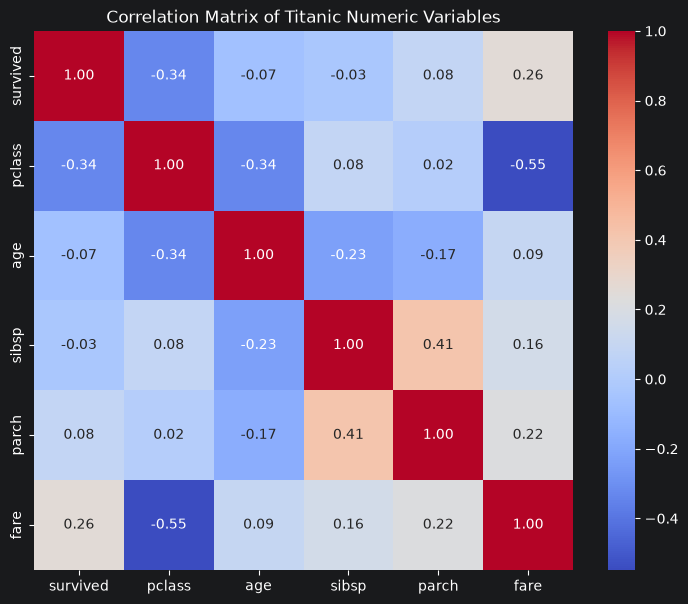

In [34]:
#Heatmap
plt.figure(figsize=(9, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    square=True
)

plt.title("Correlation Matrix of Titanic Numeric Variables")
plt.show()

In [38]:
#Find the two strongest correlations automatically
import numpy as np

corr_abs = correlation_matrix.abs()
# Keep only the upper triangle and exclude the diagonal
upper_triangle = np.triu(
    np.ones(corr_abs.shape, dtype=bool),
    k=1
)
pairs = (
    corr_abs.where(upper_triangle)
    .stack()
    .sort_values(ascending=False)
)
print("Two strongest correlations:")
for (feature1, feature2), abs_corr in pairs.head(2).items():
    actual_corr = correlation_matrix.loc[feature1, feature2]
    print(
        f"{feature1} vs {feature2}: "
        f"correlation = {actual_corr:.3f}, "
        f"absolute correlation = {abs_corr:.3f}"
    )

Two strongest correlations:
pclass vs fare: correlation = -0.548, absolute correlation = 0.548
sibsp vs parch: correlation = 0.415, absolute correlation = 0.415


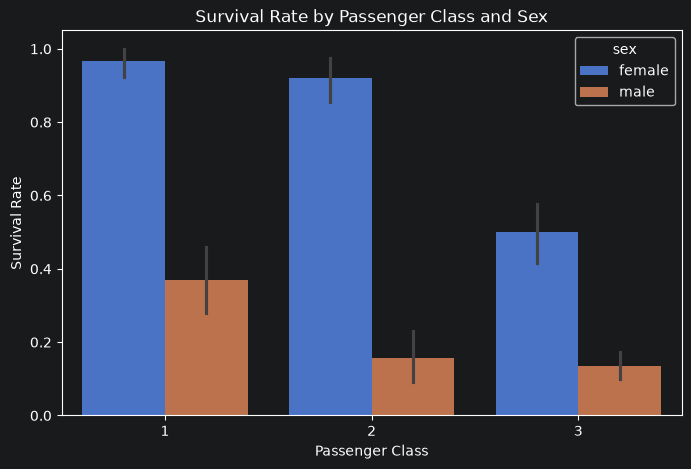

In [39]:
#Task 5 — Multivariate data story
#I recommend these four because together they tell a coherent story without producing unnecessary plots.
#Chart 1 — Survival by sex and class
plt.figure(figsize=(8, 5))
sns.barplot(
    data=df,
    x="pclass",
    y="survived",
    hue="sex"
)
plt.title("Survival Rate by Passenger Class and Sex")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.show()

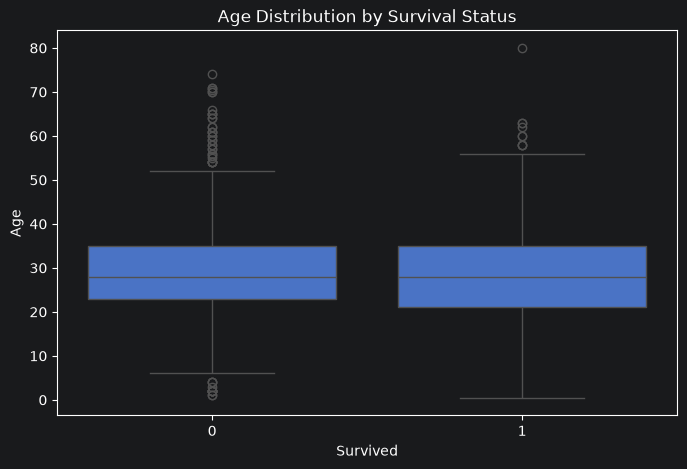

In [40]:
#Chart 2 — Age distribution by survival
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df,
    x="survived",
    y="age"
)
plt.title("Age Distribution by Survival Status")
plt.xlabel("Survived")
plt.ylabel("Age")
plt.show()

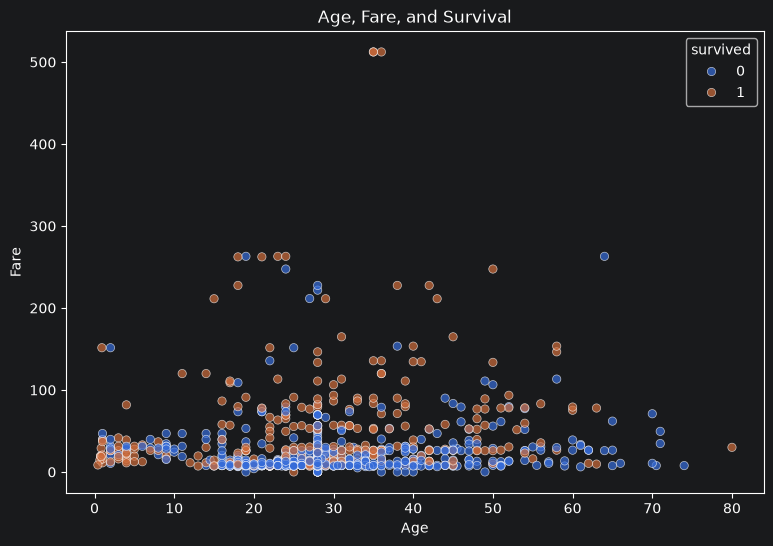

In [41]:
#Chart 3 — Fare versus age, colored by survival
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df,
    x="age",
    y="fare",
    hue="survived",
    alpha=0.7
)
plt.title("Age, Fare, and Survival")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.show()

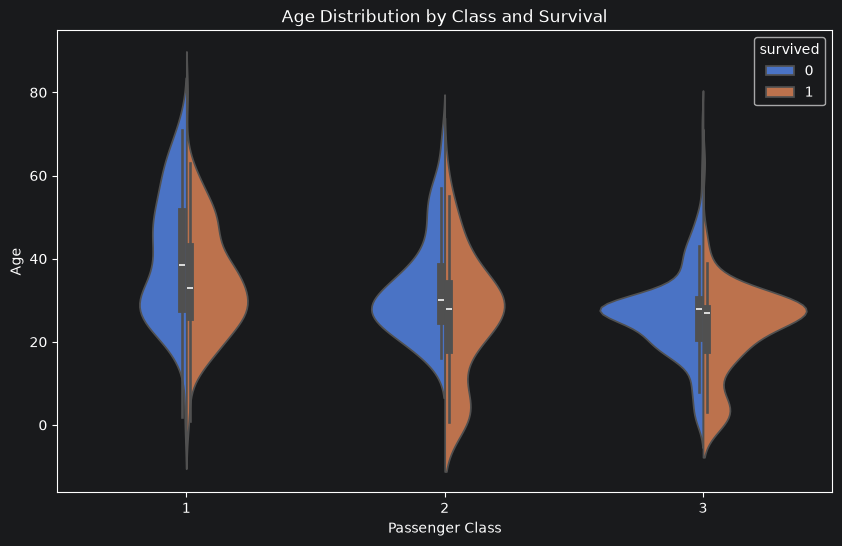

In [42]:
#Chart 4 — Survival by sex and class with age distribution
plt.figure(figsize=(10, 6))
sns.violinplot(
    data=df,
    x="pclass",
    y="age",
    hue="survived",
    split=True
)
plt.title("Age Distribution by Class and Survival")
plt.xlabel("Passenger Class")
plt.ylabel("Age")
plt.show()

In [43]:
#Task 6 — EDA standardization sanity check
from sklearn.preprocessing import StandardScaler
eda_scaled = df.copy()
scaler = StandardScaler()
eda_scaled[["age", "fare"]] = scaler.fit_transform(
    eda_scaled[["age", "fare"]]
)

In [44]:
before_stats = df[["age", "fare"]].agg(["mean", "std"]).T
after_stats = eda_scaled[["age", "fare"]].agg(["mean", "std"]).T

print("Before standardization:")
print(before_stats)

print("\nAfter standardization:")
print(after_stats)

Before standardization:
           mean        std
age   29.315152  12.984932
fare  32.096681  49.697504

After standardization:
              mean       std
age   2.717486e-16  1.000563
fare  1.398706e-16  1.000563


In [45]:
print("\nVerification:")
print("Scaled means:")
print(eda_scaled[["age", "fare"]].mean())

print("\nScaled standard deviations:")
print(eda_scaled[["age", "fare"]].std())


Verification:
Scaled means:
age     2.717486e-16
fare    1.398706e-16
dtype: float64

Scaled standard deviations:
age     1.000563
fare    1.000563
dtype: float64


In [46]:
print(eda_scaled[["age", "fare"]].std(ddof=0))

age     1.0
fare    1.0
dtype: float64
